In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from scipy.stats import randint, uniform
from xgboost import XGBClassifier, plot_importance

#读数据
df=pd.read_csv('cs-training.csv')
df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [2]:
#删除重复值和ID列
df=df.drop_duplicates()
df=df.drop(columns=['Unnamed: 0'])
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [3]:

df.isnull().sum()

SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

In [4]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtype

In [5]:
# %%
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [6]:
# %%
#发现年龄又有异常值，我们只看年龄大于18小于85的
df=df[(df['age']>=18)&(df['age']<=85)]
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,147959.000000,147959.000000,147959.000000,147959.000000,147959.000000,1.190630e+05,147959.000000,147959.000000,147959.000000,147959.000000,144325.000000
mean,0.067458,6.108627,51.789577,0.425489,355.808320,6.684716e+03,8.481559,0.269298,1.028494,0.243371,0.765204
std,0.250814,251.396724,14.221699,4.221119,2044.090262,1.443750e+04,5.149951,4.197770,1.131686,4.183599,1.118881
min,0.000000,0.000000,21.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.031176,41.000000,0.000000,0.178006,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.158559,52.000000,0.000000,0.367632,5.401000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.565791,62.000000,0.000000,0.859146,8.271000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,85.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [7]:
#发现三个逾期次数字段存在 96/98 异常值，直接删除这些异常样本
print(df['NumberOfTime30-59DaysPastDueNotWorse'].unique(),'\n')
print(df['NumberOfTime60-89DaysPastDueNotWorse'].unique(),'\n')
print(df['NumberOfTimes90DaysLate'].unique(),'\n')

late_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]

outlier_values = [96, 98]
for col in late_cols:
    df = df[~df[col].isin(outlier_values)]

df = df.copy()
df.describe()


[ 2  0  1  3  4  5  7 10  6 98 12  8  9 96 13 11] 

[ 0  1  2  5  3 98  4  6  7  8 96 11  9] 

[ 0  1  3  2  5  4 98 10  9  6  7  8 15 96 11 13 14 17 12] 



,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,147690.000000,147690.000000,147690.000000,147690.000000,147690.000000,1.189150e+05,147690.000000,147690.000000,147690.000000,147690.000000,144087.000000
mean,0.066585,6.117931,51.821532,0.247837,356.445929,6.689853e+03,8.496994,0.091360,1.030368,0.065387,0.765857
std,0.249303,251.625472,14.204009,0.700502,2045.896014,1.444543e+04,5.141912,0.487993,1.131864,0.331517,1.119182
min,0.000000,0.000000,21.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.031069,41.000000,0.000000,0.178976,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.157739,52.000000,0.000000,0.368267,5.414000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.562377,62.000000,0.000000,0.860719,8.281000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,85.000000,13.000000,329664.000000,3.008750e+06,58.000000,17.000000,54.000000,11.000000,20.000000


In [10]:
#发现RevolvingUtilizationOfUnsecuredLines、DebtRatio和MonthlyIncome有极大值
#注意：盖帽值属于从数据中学习出来的预处理参数，应在划分训练/验证集后只用训练集计算
#这里先只观察分布，真正的盖帽处理放到train_test_split之后
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,147690.000000,147690.000000,147690.000000,147690.000000,147690.000000,1.189150e+05,147690.000000,147690.000000,147690.000000,147690.000000,144087.000000
mean,0.066585,6.117931,51.821532,0.247837,356.445929,6.689853e+03,8.496994,0.091360,1.030368,0.065387,0.765857
std,0.249303,251.625472,14.204009,0.700502,2045.896014,1.444543e+04,5.141912,0.487993,1.131864,0.331517,1.119182
min,0.000000,0.000000,21.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.031069,41.000000,0.000000,0.178976,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.157739,52.000000,0.000000,0.368267,5.414000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.562377,62.000000,0.000000,0.860719,8.281000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,85.000000,13.000000,329664.000000,3.008750e+06,58.000000,17.000000,54.000000,11.000000,20.000000


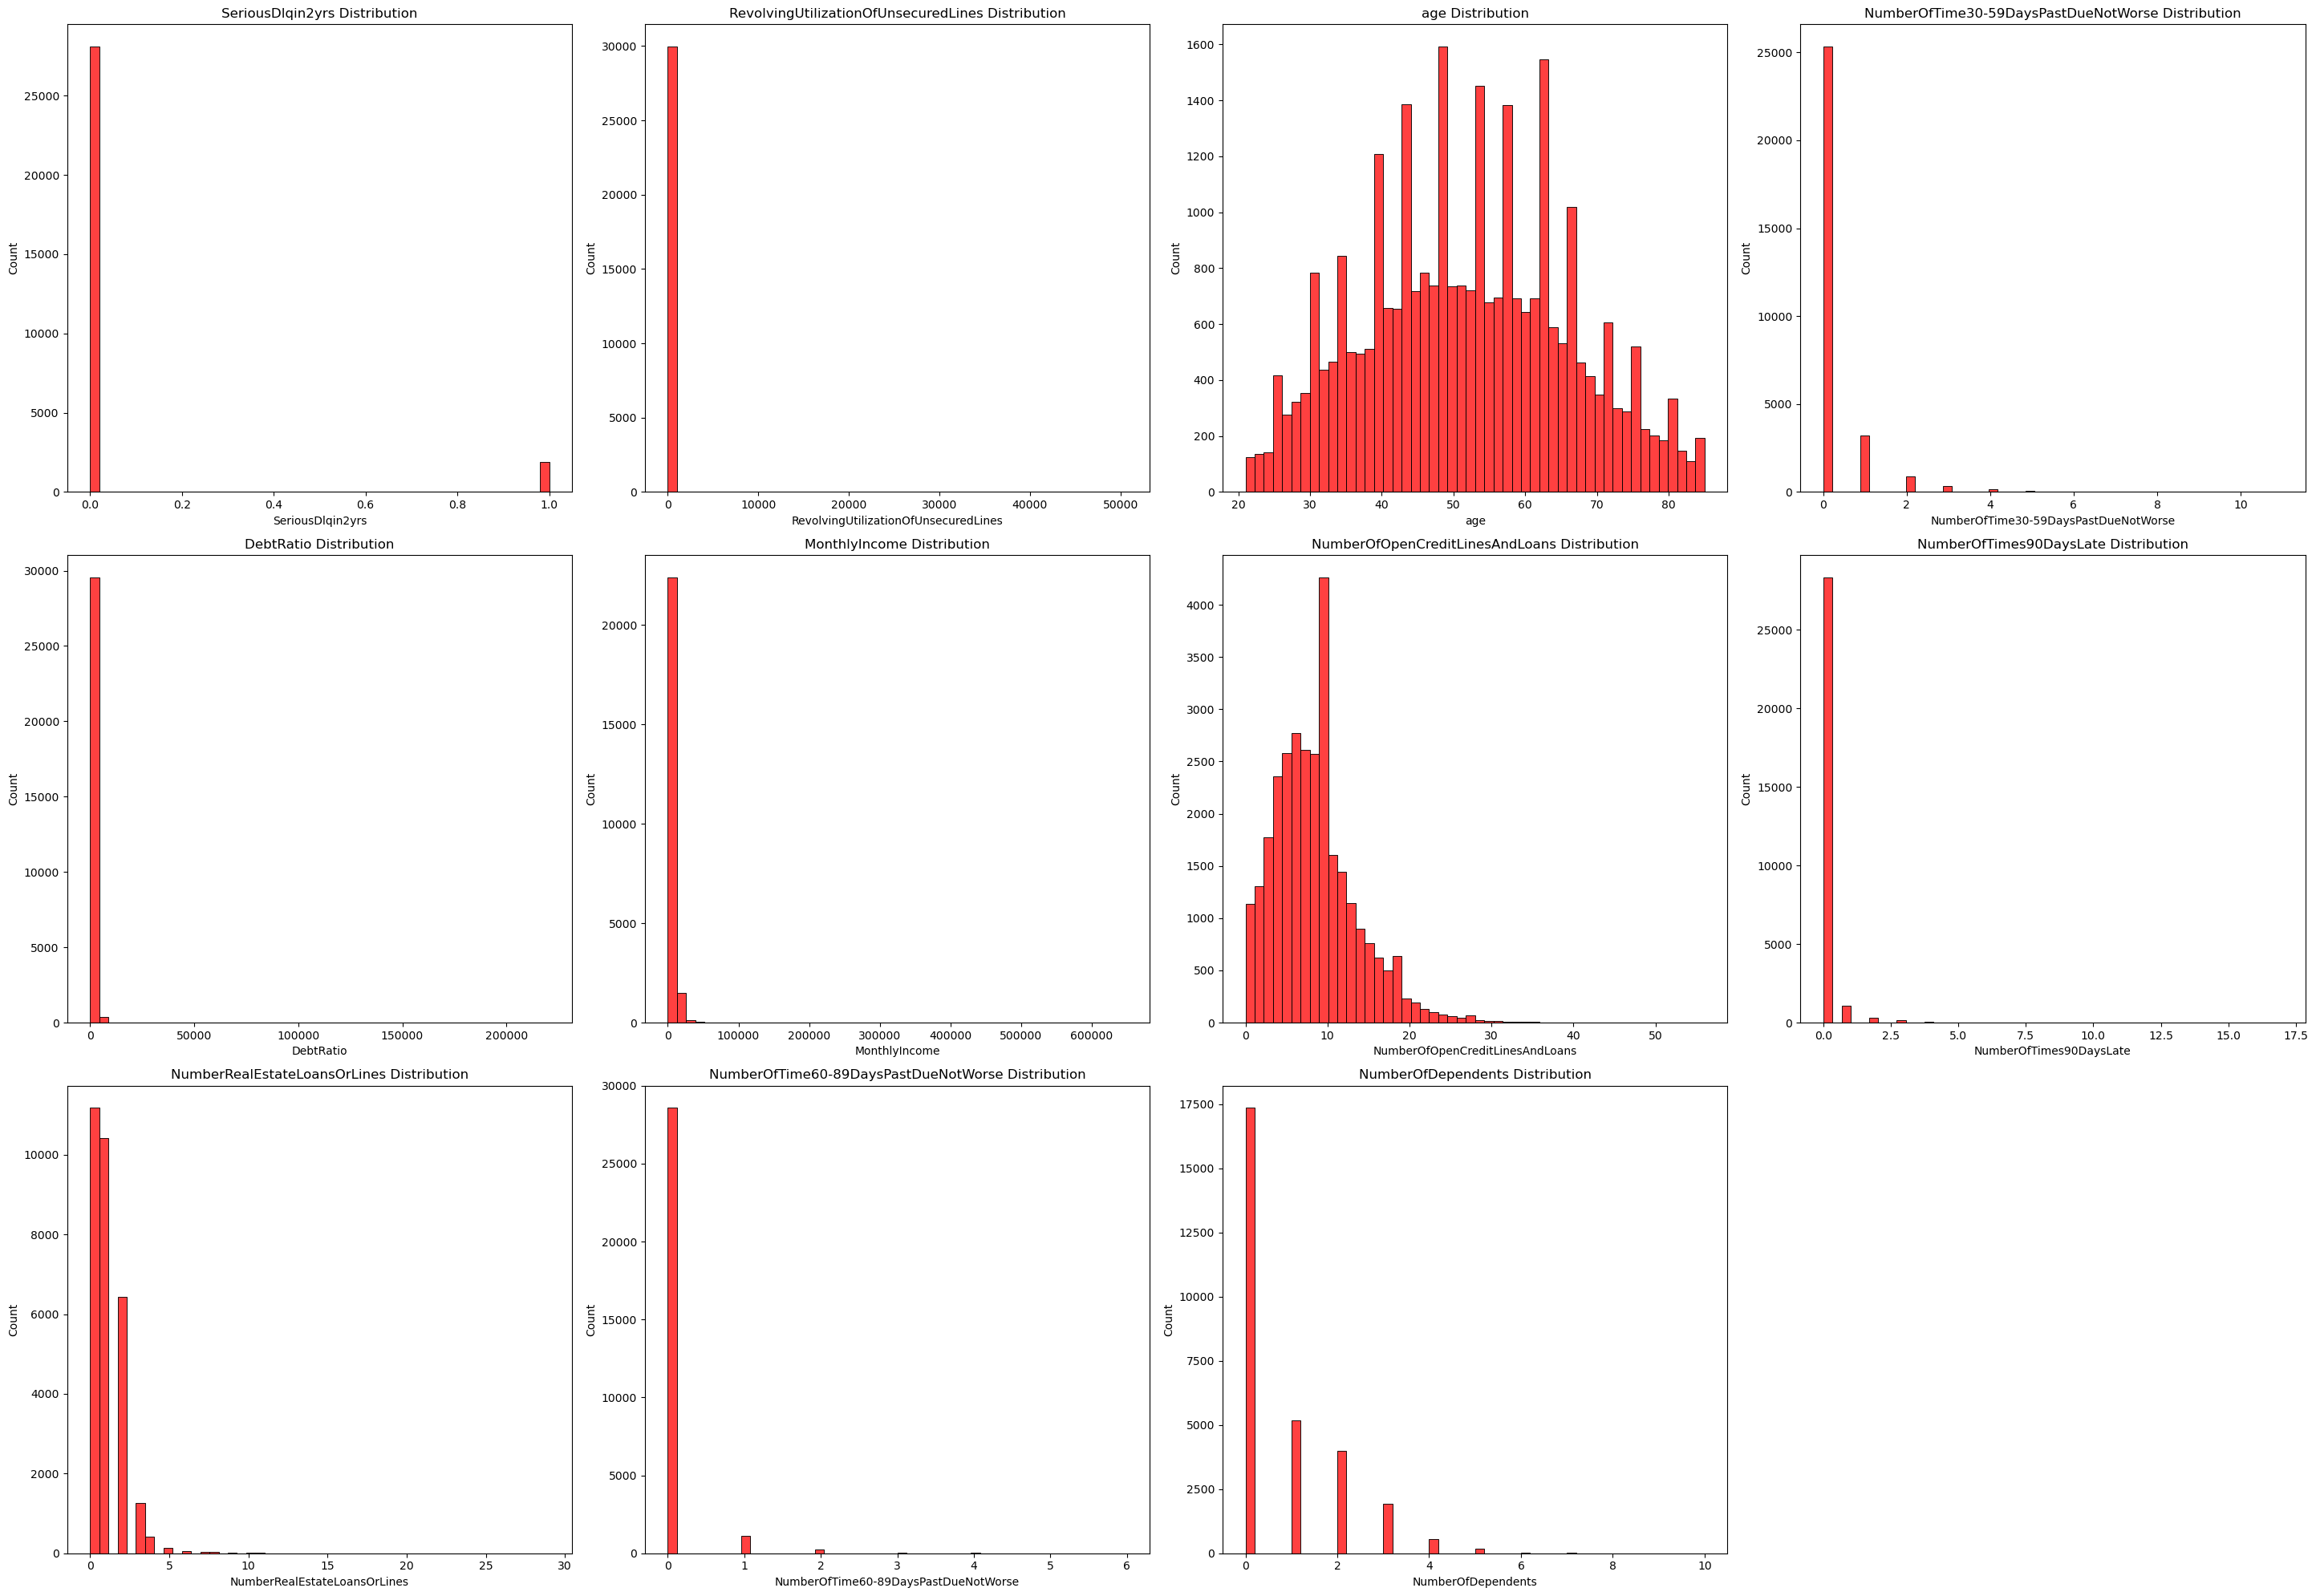

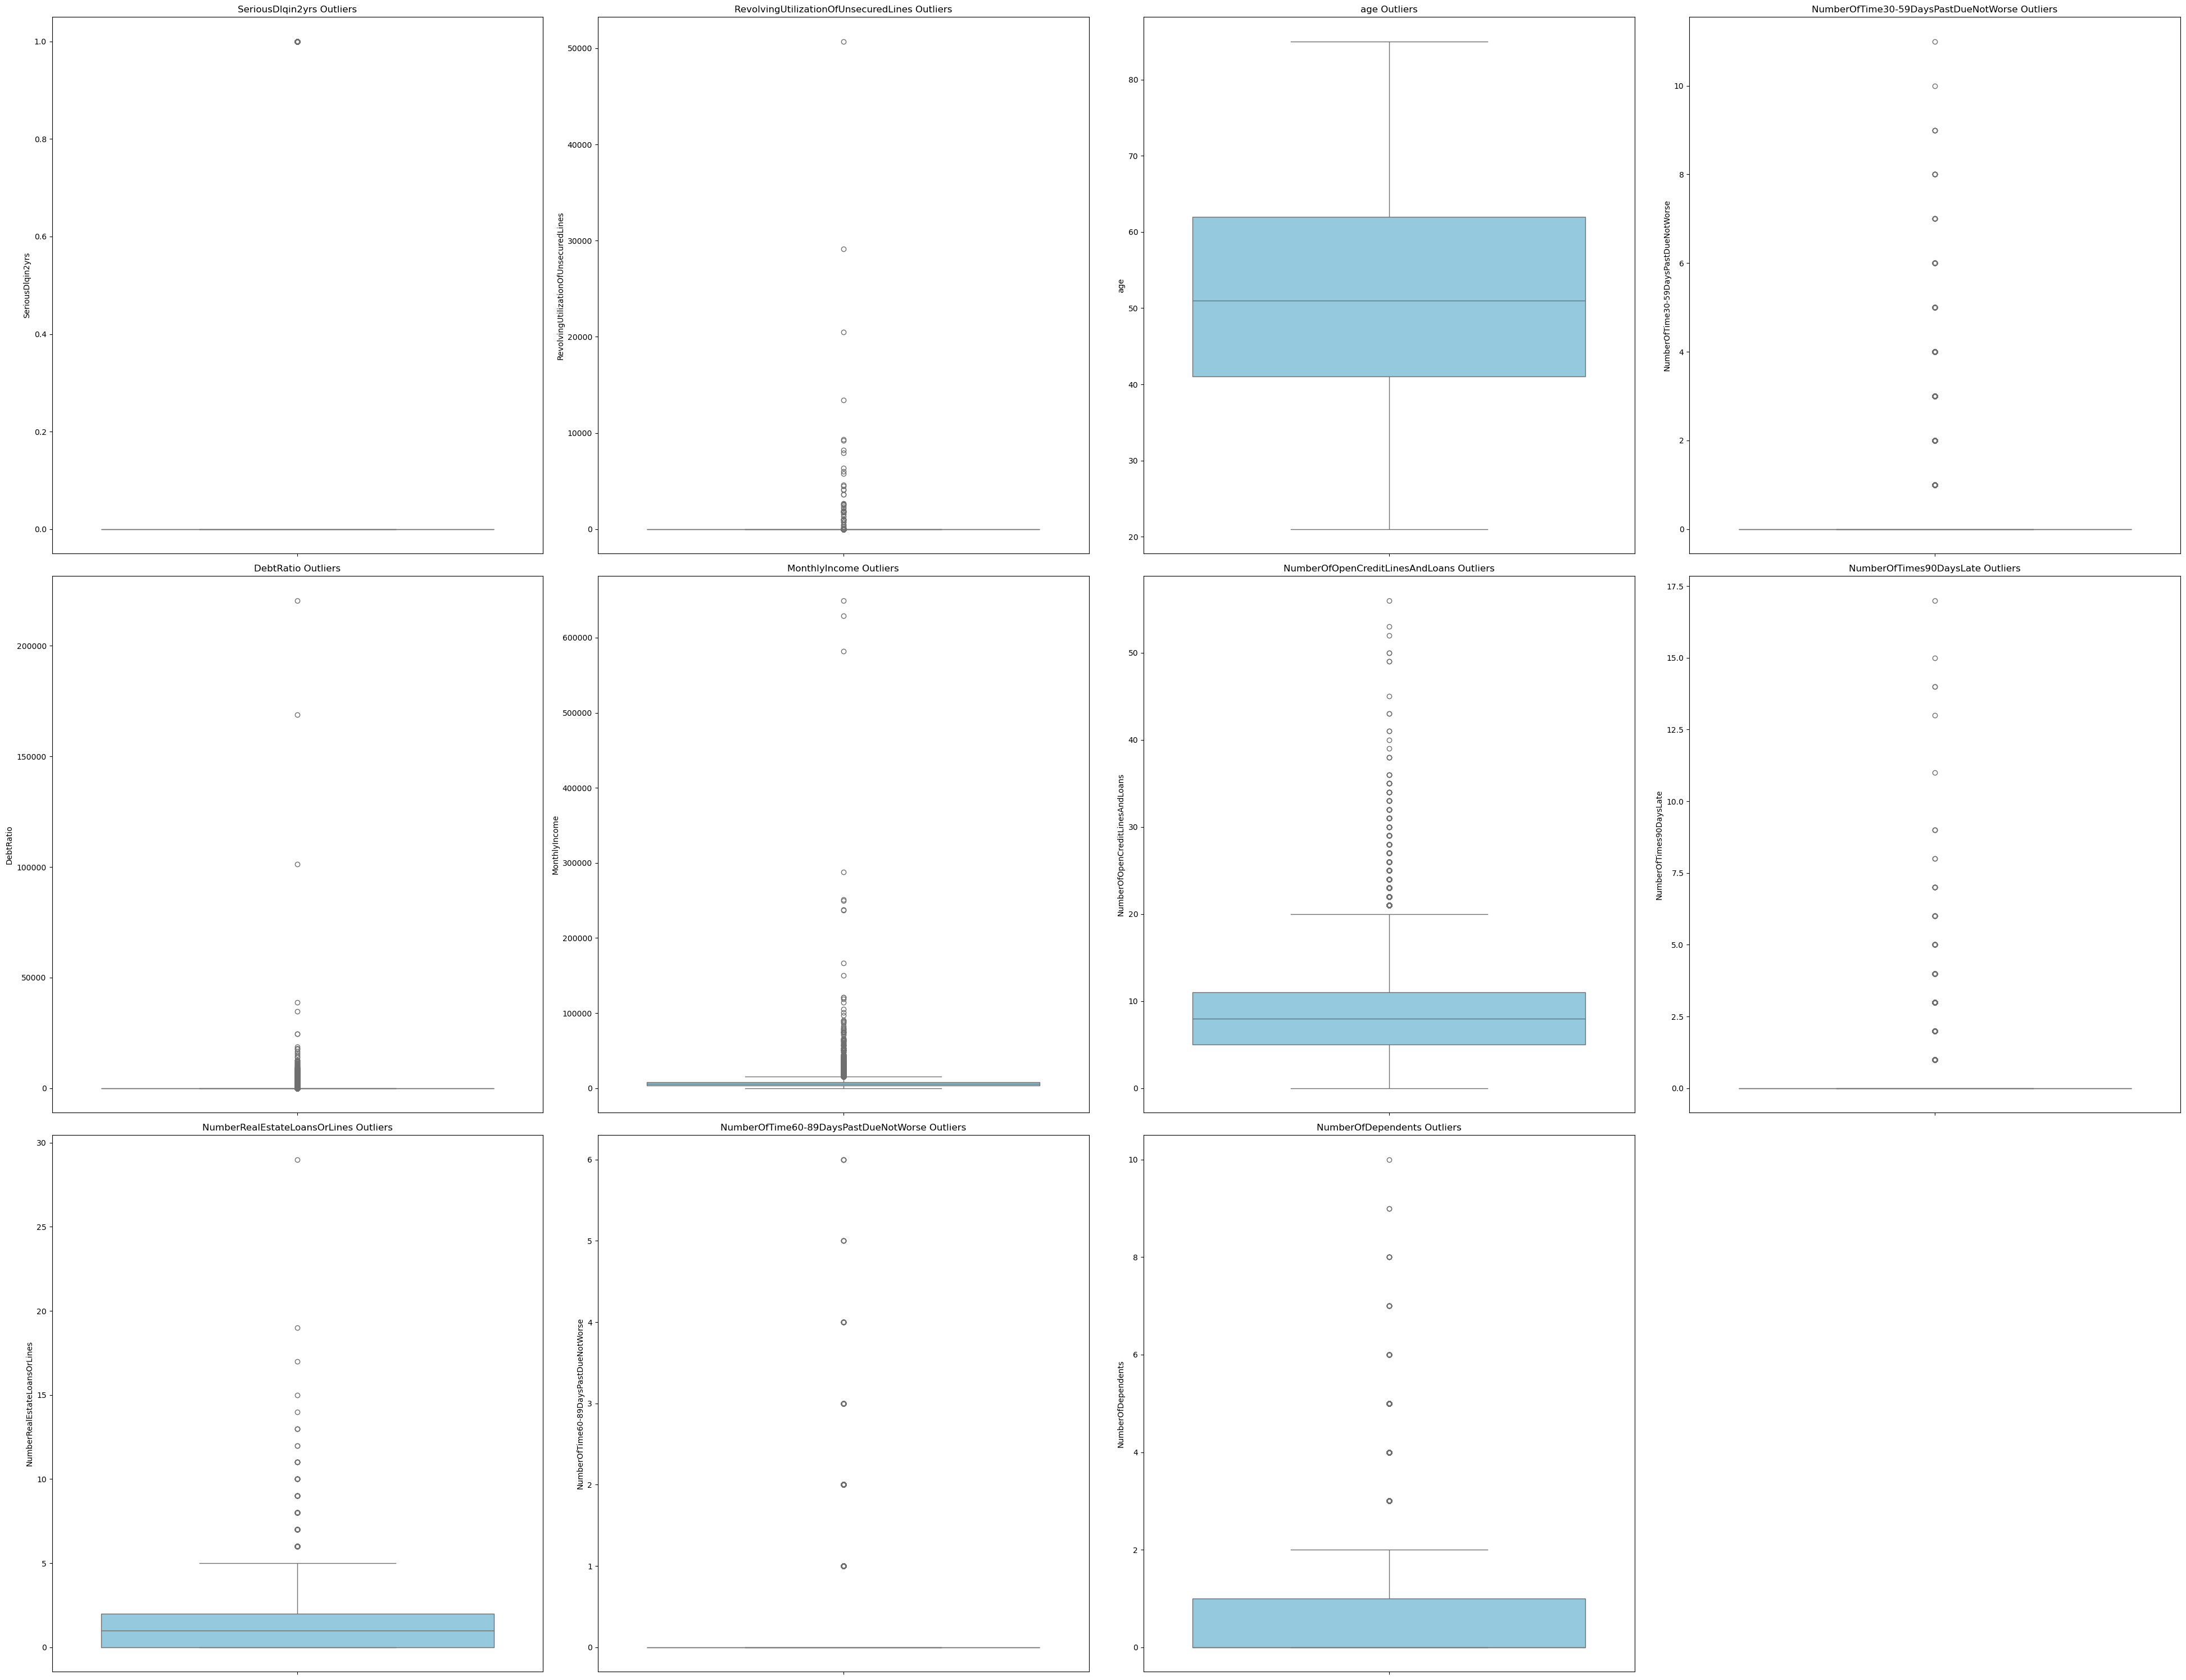

In [8]:
#抽样画his,box图
plot_df = df.sample(n=30000, random_state=42)

select_index = plot_df.select_dtypes(include=['float64', 'int64']).columns
n_col = 4
n_row = math.ceil(len(select_index) / n_col)

plt.figure(figsize=(29, 20))
for i, col in enumerate(select_index):
    plt.subplot(n_row, n_col, i + 1)
    sns.histplot(x=plot_df[col], bins=50, kde=False, color='red')
    plt.title(f'{col} Distribution')
plt.tight_layout()
plt.show()

plt.figure(figsize=(39, 30))
for i, col in enumerate(select_index):
    plt.subplot(n_row, n_col, i + 1)
    sns.boxplot(y=plot_df[col], color='skyblue')
    plt.title(f'{col} Outliers')
plt.tight_layout()
plt.show()

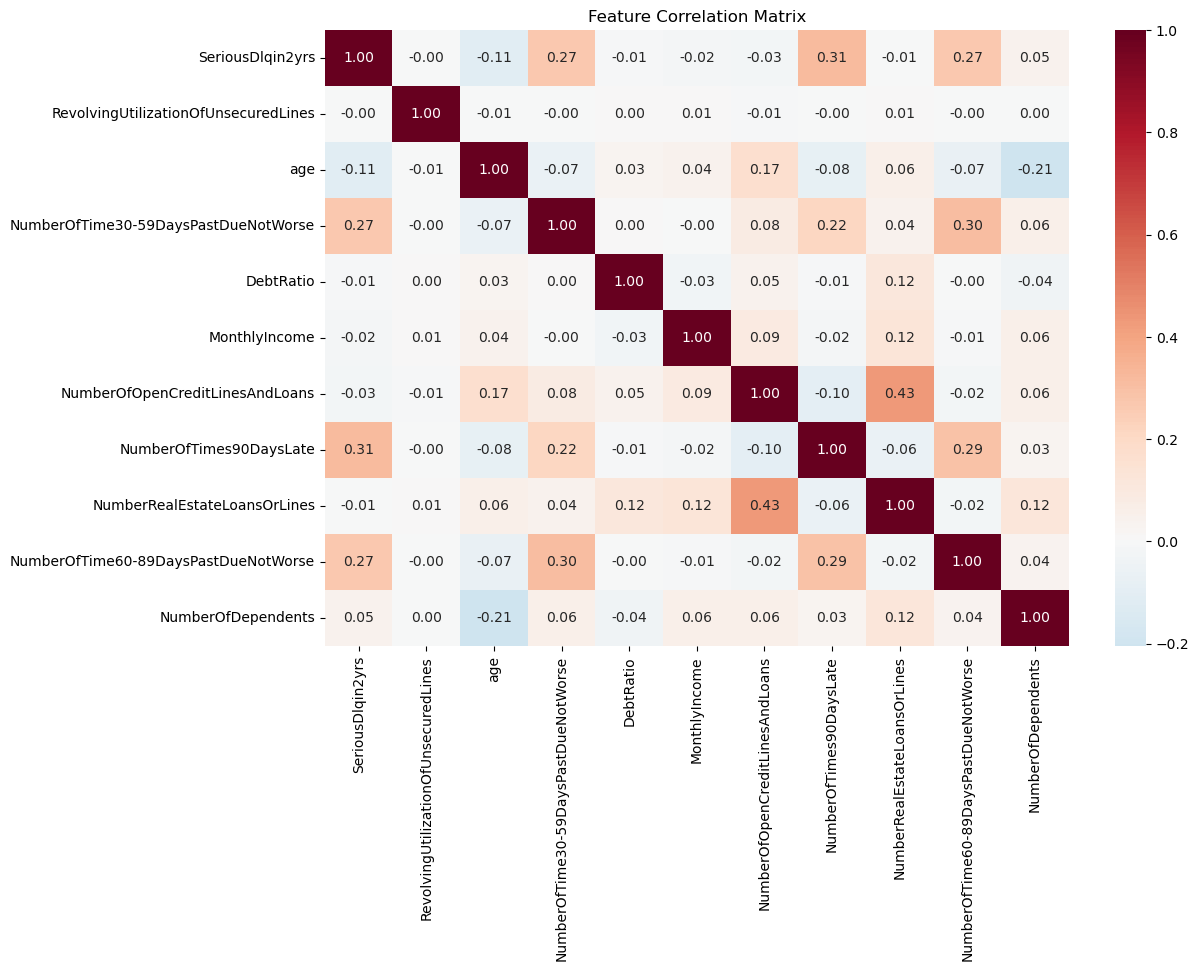

In [9]:
#画热力图看共线性
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()
#结果发现没有共线性

In [10]:
#线性
df_lin=df.copy()
df_lin.describe()
df_lin.isna().sum()



SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           28775
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3603
dtype: int64

In [11]:
#1. 先把那些填固定 0 的处理掉 (因为 0 不涉及泄露)
cols_fill_zero = ['NumberOfDependents', 'NumberOfTime30-59DaysPastDueNotWorse', 
                  'NumberOfTimes90DaysLate', 'NumberOfTime60-89DaysPastDueNotWorse']
df_lin[cols_fill_zero] = df_lin[cols_fill_zero].fillna(0)
df_lin.isna().sum()

SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           28775
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                          0
dtype: int64

In [ ]:
#分训练集，对于线性的
y = df_lin['SeriousDlqin2yrs']
X = df_lin.drop(columns=['SeriousDlqin2yrs'])
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train = X_train.copy()
X_val = X_val.copy()

#缺失值填补：只用训练集计算MonthlyIncome中位数，再应用到训练集和验证集，避免数据泄露
income_median = X_train['MonthlyIncome'].median()
X_train['MonthlyIncome'] = X_train['MonthlyIncome'].fillna(income_median)
X_val['MonthlyIncome'] = X_val['MonthlyIncome'].fillna(income_median)

#极端值盖帽：只用训练集计算99%分位数，再应用到训练集和验证集
# 选择需要进行极端值截尾处理的连续变量
cap_cols = [
    'RevolvingUtilizationOfUnsecuredLines',
    'DebtRatio',
    'MonthlyIncome'
]

# 创建一个空字典，用来保存每个变量对应的截尾上限
# 例如循环运行完之后，可能会得到：
# cap_values = {
#     'RevolvingUtilizationOfUnsecuredLines': 1.09,
#     'DebtRatio': 4979.04,
#     'MonthlyIncome': 25000.0
# }
cap_values = {}

for col in cap_cols:
    
    # 计算当前变量在训练集 X_train 中的 99% 分位数
    # 这一步会为当前变量生成一个数值型上限
    # 例如：
    # 如果 col = 'MonthlyIncome'
    # 那么 cap_values['MonthlyIncome'] 可能会变成 25000.0
    #
    # 注意：这里只用训练集 X_train 来计算上限
    # 不能用验证集 X_val，否则会造成数据泄露 data leakage
    cap_values[col] = X_train[col].quantile(0.99)
    
    # 使用刚才从训练集得到的上限，对训练集进行截尾处理
    # 如果某个值大于 cap_values[col]，就把它替换成 cap_values[col]
    # 如果某个值小于或等于 cap_values[col]，就保持原值不变
    X_train[col] = X_train[col].clip(upper=cap_values[col])
    
    # 对验证集也使用同一个训练集得到的上限进行截尾
    # 注意：这里不能重新用 X_val 自己的 99% 分位数
    # 因为验证集只能用来验证模型，不能参与预处理规则的学习
    X_val[col] = X_val[col].clip(upper=cap_values[col])
#收入取log，降低长尾分布影响
X_train['MonthlyIncome_Log'] = np.log1p(X_train['MonthlyIncome'])
X_val['MonthlyIncome_Log'] = np.log1p(X_val['MonthlyIncome'])

/var/folders/78/ybdcl4q5711d5k_18zhq224h0000gn/T/ipykernel_73460/492080388.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target, y=col, data=df_train, showfliers=False, palette='Set2')
/var/folders/78/ybdcl4q5711d5k_18zhq224h0000gn/T/ipykernel_73460/492080388.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target, y=col, data=df_train, showfliers=False, palette='Set2')
/var/folders/78/ybdcl4q5711d5k_18zhq224h0000gn/T/ipykernel_73460/492080388.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target, y=col, data=df_train,

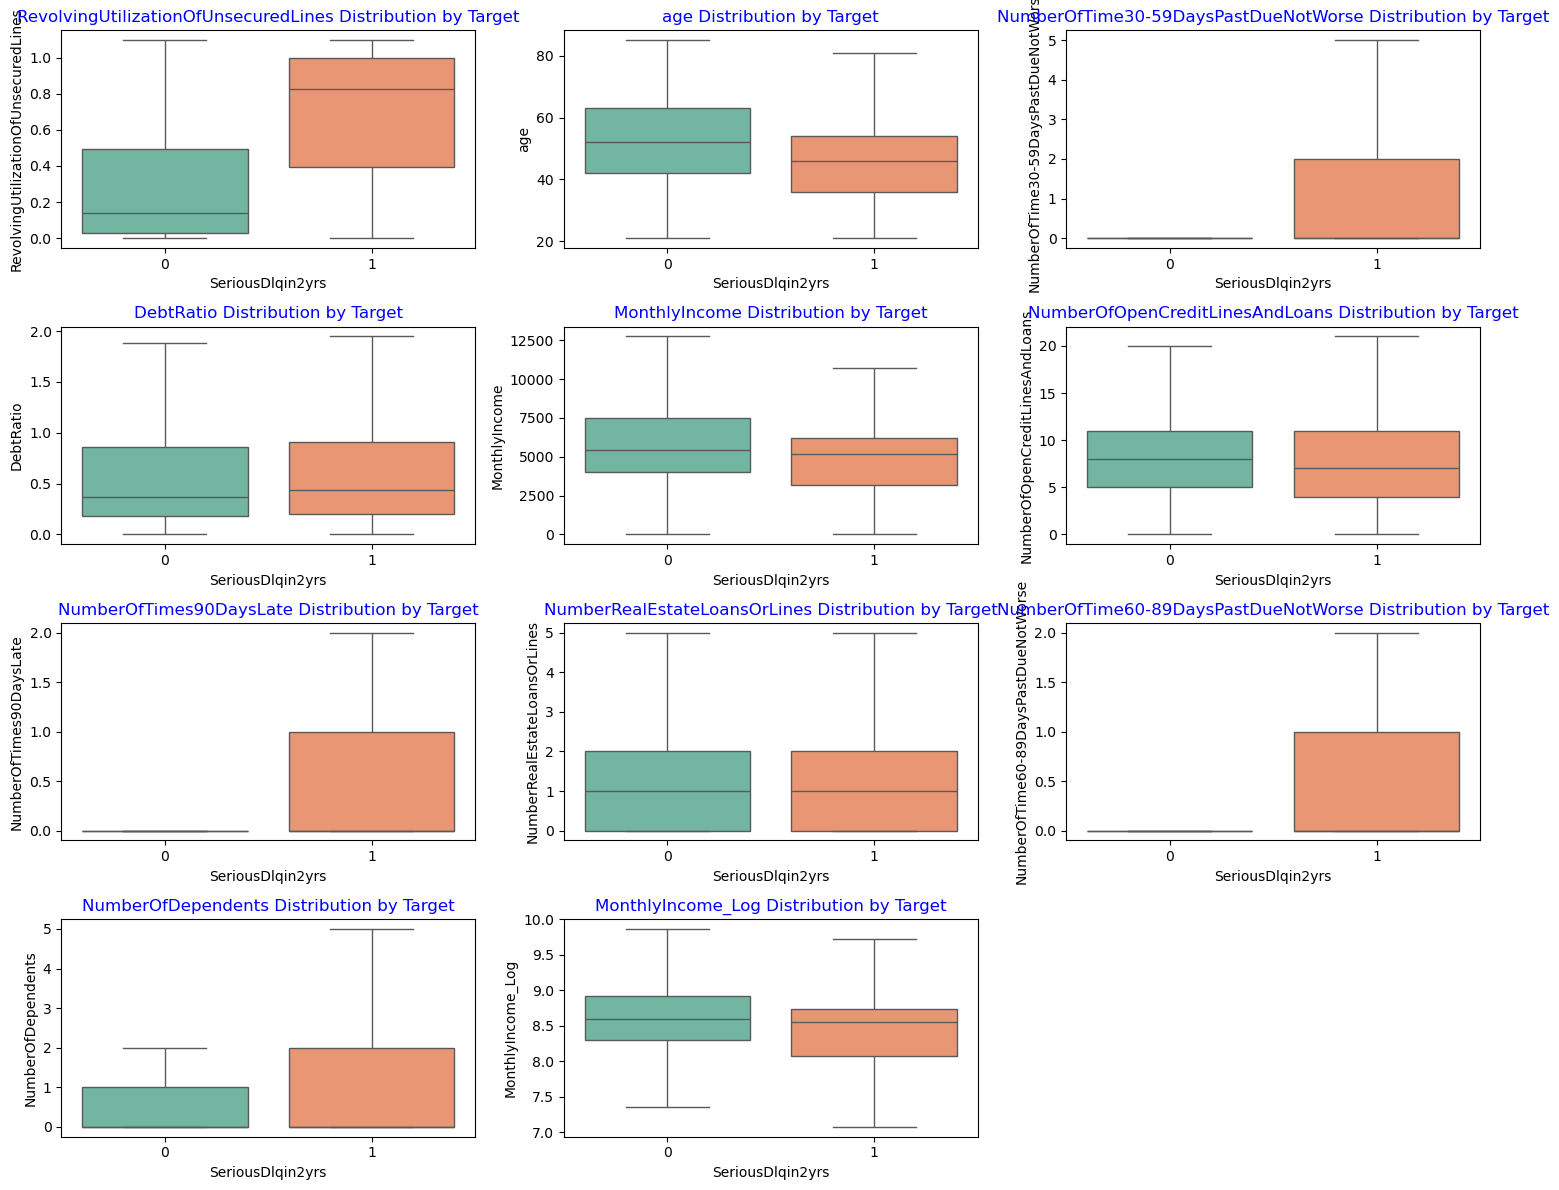

In [13]:
#利用双变量分析”（Bivariate Analysi）查看分箱,要在分了训练集后，防止数据泄漏
df_train = X_train.copy()
df_train['SeriousDlqin2yrs'] = y_train
target='SeriousDlqin2yrs'
features=df_train.drop(columns=[target]).select_dtypes(include=['float64','int64']).columns
plt.figure(figsize=(15, 12))

for i, col in enumerate(features):
        plt.subplot(4, 3, i+1)
        
        # --- 策略 A: 如果是“少值特征” (比如 Overdue 只有5个值) ---
        # 我们画“违约率图”：看逾期次数越多，坏人比例是不是越高？
        if df_train[col].nunique() < 10:
            # 计算每个值的违约率 (Mean of Target)
            sns.barplot(x=col, y=target, data=df_train, errorbar=None, palette='Reds')
            plt.title(f'{col}: Default Rate (Higher is Worse)', color='red')
            plt.ylabel('Probability of Default')
            
        # --- 策略 B: 如果是“连续特征” (比如 Age, DebtRatio) ---
        # 我们画“箱线图”：对比好人(0)和坏人(1)的分布差异
        #看 target=0 和 target=1 的两个箱子，
        # 在 y 轴方向上是否明显分开。
        #明显有区分不再同一水平线就说明这个x要分箱，反之就不用
        else:
            sns.boxplot(x=target, y=col, data=df_train, showfliers=False, palette='Set2')
            plt.title(f'{col} Distribution by Target', color='blue')
            # 0是好人，1是坏人
    
plt.tight_layout()
plt.show()

In [26]:
# 导入决策树模型（用于找最优切分点）
from sklearn.tree import DecisionTreeClassifier

# 导入 numpy（用于处理无穷大等数值）
import numpy as np


# 决策树分箱函数

def tree_binning(x, y, max_leaf_nodes=4):
    """
    功能：
    用决策树自动寻找最优切分点(cut points),并生成分箱边界
    
    参数：
    x : 一维变量（如 age、income),通常是 pandas 的 Series
    y : 标签(0/1),表示好坏客户
    max_leaf_nodes : 最大叶子节点数（即最多分成多少个箱）
    
    返回：
    bins : 分箱边界列表，例如 [-inf, 25, 40, 60, inf]
    """

    
    # Step 1：数据格式转换

    # sklearn 要求输入是二维数组 (样本数, 特征数)
    # 但 x 是一维的，所以需要 reshape 成 (n,1)
    x = x.values.reshape(-1, 1)
    


    # Step 2：定义决策树模型

    clf = DecisionTreeClassifier(
        max_leaf_nodes=max_leaf_nodes,   # 限制最多分成多少个叶子节点（即最多多少个箱）
        
        min_samples_leaf=0.05            # 每个叶子节点至少包含5%的样本
        #作用：防止分箱太细、避免过拟合、保证每箱稳定
    )
    


    # Step 3：训练决策树

    # 决策树会自动寻找最优切分点，使得每个分段里的 y 尽量“纯”（好坏区分明显）
    clf.fit(x, y)
    


    # Step 4：提取切分阈值（核心）

    # tree_.threshold 包含所有节点的切分点
    thresholds = clf.tree_.threshold
    
    # 在 sklearn 中：
    # threshold = -2 表示该节点是叶子节点（不是切分点）
    # 所以这里把无效值去掉
    thresholds = thresholds[thresholds != -2]
    


    # Step 5：构造分箱区间

    # 例如 thresholds = [25, 40, 60]
    # 最终 bins = [-inf, 25, 40, 60, inf]
    
    bins = [-np.inf] + sorted(thresholds) + [np.inf]
    
    #sorted 是为了保证切点从小到大排序（防止树返回乱序）
    

    # Step 6：返回分箱边界
    return bins

In [27]:
# 学分箱（只用训练集）
bin_dict = {}

bin_dict['age'] = tree_binning(X_train['age'], y_train)
bin_dict['rev'] = tree_binning(X_train['RevolvingUtilizationOfUnsecuredLines'], y_train)
bin_dict['debt'] = tree_binning(X_train['DebtRatio'], y_train)
bin_dict['income'] = tree_binning(X_train['MonthlyIncome_Log'], y_train)
bin_dict['open_credit'] = tree_binning(X_train['NumberOfOpenCreditLinesAndLoans'], y_train)
bin_dict['real_estate'] = tree_binning(X_train['NumberRealEstateLoansOrLines'], y_train)

In [28]:
# 1. 定义一个处理函数 (把刚才所有的分箱逻辑都放进去)
def process_binning(df_input, bin_dict):
    # 为了不修改原始数据，创建一个副本
    df = df_input.copy()
    # 连续变量：tree分箱 
    df['Age'] = pd.cut(df['age'], bins=bin_dict['age'])
    
    df['Rev'] = pd.cut(
        df['RevolvingUtilizationOfUnsecuredLines'],
        bins=bin_dict['rev']
    )
    
    df['DebtRatio_Bin'] = pd.cut(
        df['DebtRatio'],
        bins=bin_dict['debt']
    )
    
    df['Income_Bin'] = pd.cut(
        df['MonthlyIncome_Log'],
        bins=bin_dict['income']
    )
    
    df['OpenCredit_Bin'] = pd.cut(
        df['NumberOfOpenCreditLinesAndLoans'],
        bins=bin_dict['open_credit']
    )
    
    df['RealEstate_Bin'] = pd.cut(
        df['NumberRealEstateLoansOrLines'],
        bins=bin_dict['real_estate']
    )
    # 离散变量：保持原样 
    
    # 30-59天逾期：切分成 [0次], [1次], [2次], [3次及以上]
    df['30-59Days_Bin'] = pd.cut(df['NumberOfTime30-59DaysPastDueNotWorse'], bins=[-1, 0, 1, 2, 100], labels=['Never_30_59', 'Once_30_59', 'Twice_30_59', 'More_30_59'])
    # 60-89天逾期：切分成 [0次], [1次], [2次及以上]
    df['60-89Days_Bin'] = pd.cut(df['NumberOfTime60-89DaysPastDueNotWorse'], bins=[-1, 0, 1, 100], labels=['Never_60_89', 'Once_60_89', 'More_60_89'])

    # 90天+逾期：切分成 [0次], [1次], [2次及以上]
    df['90Days_Bin'] = pd.cut(df['NumberOfTimes90DaysLate'], bins=[-1, 0, 1, 100], labels=['Never_90', 'Once_90', 'More_90'])

    # 针对家属数量分箱：0, 1, 2, 3+
    # bins=[-1, 0, 1, 2, 100] 的逻辑是：
    # (-1, 0] -> 0
    # (0, 1]  -> 1
    # (1, 2]  -> 2
    # (2, 100]-> 3到100 (即3个及以上)
    df['Dependents_Bin'] = pd.cut(df['NumberOfDependents'], bins=[-1, 0, 1, 2, 100], labels=['No_Dep', 'One_Dep', 'Two_Dep', 'More_Dep'])

    return df

In [29]:
# WOE 和 IV 计算函数
# 一个特征（feature）会被分成多个箱，每个箱都有自己的 WOE 和 IV 贡献
# 所有箱子的 IV_component 加总后，就是这个特征的 IV

def calculate_woe_iv(df, feature, target):
    # 1. 按分箱变量分组，统计每个箱的总样本数和坏样本数
    # observed=True 用于只保留真实出现过的类别，同时避免 pandas 的 FutureWarning
    grouped = df.groupby(feature, observed=True)[target].agg(['count', 'sum'])
    
    # 2. 重命名字段，total 表示该箱总样本数，bad 表示该箱坏样本数
    grouped.columns = ['total', 'bad']
    
    # 3. 计算好样本数和坏账率
    # bad_rate 是风控报告里解释分箱风险趋势的重要指标
    grouped['good'] = grouped['total'] - grouped['bad']
    grouped['bad_rate'] = grouped['bad'] / grouped['total']
    
    # 4. 计算训练集中整体好样本数和坏样本数
    total_good = grouped['good'].sum()
    total_bad = grouped['bad'].sum()
    
    # 5. 计算每个箱的好样本占比和坏样本占比
    # WOE 衡量的是该箱内好坏客户分布相对整体的偏离程度
    grouped['good_pct'] = grouped['good'] / total_good
    grouped['bad_pct'] = grouped['bad'] / total_bad
    
    # 6. 计算 WOE
    # 加 1e-6 是为了避免某个箱 good 或 bad 为 0 时出现 log(0)
    grouped['WOE'] = np.log(
        (grouped['good_pct'] + 1e-6) /
        (grouped['bad_pct'] + 1e-6)
    )
    
    # 7. 计算每个箱对 IV 的贡献
    grouped['IV_component'] = (
        grouped['good_pct'] - grouped['bad_pct']
    ) * grouped['WOE']
    
    # 8. 汇总得到该变量整体 IV
    iv = grouped['IV_component'].sum()
    
    return grouped, iv


In [30]:
# 要做 WOE 的列
bin_cols = [
    'Age','Rev',
    'DebtRatio_Bin','Income_Bin',
    'OpenCredit_Bin','RealEstate_Bin',
    '30-59Days_Bin','60-89Days_Bin','90Days_Bin',
    'Dependents_Bin'
]

# 分箱
df_train_bin = process_binning(X_train, bin_dict)
df_train_bin['target'] = y_train

# 计算 WOE map + IV
# woe_maps：保存每个变量的 {分箱: WOE} 映射，后面用于把 train/validation 转成 WOE 数值
woe_maps = {}

# iv_summary：保存每个变量的整体 IV，用于变量预测能力排序
iv_summary = {}

# woe_detail_list：保存所有变量的分箱明细，后面合并成一张干净的 report 表
# 表结构统一为 feature + bin + total/bad/good/bad_rate/WOE/IV_component/IV，避免不同变量分箱列互相产生大量 NaN
woe_detail_list = []

# 遍历所有分箱变量
for col in bin_cols:

    # Step 1：计算当前变量的 WOE 表和整体 IV
    woe_table, iv_value = calculate_woe_iv(df_train_bin, col, 'target')
    
    # Step 2：整理当前变量的 WOE 明细表
    # reset_index 后，当前变量的分箱列名是 col；统一重命名为 bin，方便展示和写 report
    woe_table_report = woe_table.reset_index().rename(columns={col: 'bin'})
    woe_table_report['feature'] = col
    woe_table_report['IV'] = iv_value
    
    # Step 3：调整列顺序，让表更清楚
    report_cols = [
        'feature', 'bin', 'total', 'bad', 'good', 'bad_rate',
        'good_pct', 'bad_pct', 'WOE', 'IV_component', 'IV'
    ]
    woe_table_report = woe_table_report[report_cols]
    woe_detail_list.append(woe_table_report)
    
    # Step 4：保存 WOE 映射（分箱 -> WOE）
    # 这个字典后面用于把训练集和验证集的分箱结果转换成 WOE 数值
    woe_maps[col] = woe_table['WOE'].to_dict()

    # Step 5：保存该变量的整体 IV
    iv_summary[col] = iv_value

# 合并所有变量的 WOE 明细表
# 这是一张长表，不再为每个变量单独生成一列，因此展示时不会出现大量 NaN
woe_detail_df = pd.concat(woe_detail_list, ignore_index=True)

# 把 IV 字典转换成 DataFrame
iv_df = pd.DataFrame({
    'feature': list(iv_summary.keys()),   # 特征名
    'IV': list(iv_summary.values())       # 对应 IV 值
})

# 按 IV 从大到小排序（IV 越大，变量区分好坏客户的能力越强）
iv_df = iv_df.sort_values(by='IV', ascending=False)

def iv_strength(iv):
    if iv < 0.02:
        return 'useless'
    elif iv < 0.1:
        return 'weak'
    elif iv < 0.3:
        return 'medium'
    elif iv < 0.5:
        return 'strong'
    else:
        return 'suspiciously strong'

iv_df['strength'] = iv_df['IV'].apply(iv_strength)

print(iv_df)

# 展示 IV 最高的前 5 个变量的分箱明细，用于检查坏账率和 WOE 是否符合风险趋势
top_iv_features = iv_df.head(5)['feature'].tolist()
woe_detail_df[woe_detail_df['feature'].isin(top_iv_features)]


          feature        IV             strength
1             Rev  1.006173  suspiciously strong
8      90Days_Bin  0.825180  suspiciously strong
6   30-59Days_Bin  0.727997  suspiciously strong
7   60-89Days_Bin  0.555650  suspiciously strong
0             Age  0.233019               medium
2   DebtRatio_Bin  0.077361                 weak
3      Income_Bin  0.074983                 weak
4  OpenCredit_Bin  0.064226                 weak
5  RealEstate_Bin  0.054347                 weak
9  Dependents_Bin  0.032309                 weak


,feature,bin,total,bad,good,bad_rate,good_pct,bad_pct,WOE,IV_component,IV
0,Age,"(-inf, 36.5]",19036,2043,16993,0.107323,0.154083,0.259692,-0.522006,0.055129,0.233019
1,Age,"(36.5, 55.5]",51213,4081,47132,0.079687,0.427365,0.518749,-0.193781,0.017708,0.233019
2,Age,"(55.5, 62.5]",19160,973,18187,0.050783,0.164909,0.123681,0.287685,0.011861,0.233019
3,Age,"(62.5, inf]",28743,770,27973,0.026789,0.253643,0.097877,0.952207,0.148321,0.233019
4,Rev,"(-inf, 0.385]",78815,1940,76875,0.024615,0.697058,0.246600,1.039099,0.468070,1.006173
5,Rev,"(0.385, 0.678]",14798,1187,13611,0.080214,0.123417,0.150883,-0.200940,0.005519,1.006173
6,Rev,"(0.678, 0.883]",8012,1147,6865,0.143160,0.062248,0.145799,-0.851096,0.071110,1.006173
7,Rev,"(0.883, inf]",16527,3593,12934,0.217402,0.117278,0.456718,-1.359513,0.461473,1.006173
24,30-59Days_Bin,Never_30_59,99268,4000,95268,0.040295,0.863835,0.508453,0.530008,0.188355,0.727997
25,30-59Days_Bin,Once_30_59,12693,1899,10794,0.149610,0.097874,0.241388,-0.902722,0.129554,0.727997


In [19]:
#应用 WOE（train + val）
#如果验证集或未来样本出现训练集中未见过的箱，使用默认WOE=0，表示按整体平均风险处理
#注意：分箱后的变量是 Categorical 类型，map 后需要先转成 float，再 fillna，避免类别型变量不能填入新值的问题
def apply_woe(df, woe_maps, default_woe=0):
    df = df.copy()
    
    for col, mapping in woe_maps.items():
        mapped_woe = df[col].map(mapping).astype('float64')
        df[col] = mapped_woe.fillna(default_woe)
    
    return df


In [20]:
# 分箱
X_train_bin = process_binning(X_train, bin_dict)
X_val_bin   = process_binning(X_val, bin_dict)

# WOE转换
X_train_woe = apply_woe(X_train_bin, woe_maps)
X_val_woe   = apply_woe(X_val_bin, woe_maps)

# 删除原始列（重要！）
drop_cols = [
    'age','RevolvingUtilizationOfUnsecuredLines',
    'DebtRatio','MonthlyIncome','MonthlyIncome_Log',
    'NumberOfOpenCreditLinesAndLoans','NumberRealEstateLoansOrLines',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfDependents'
]

X_train_woe = X_train_woe.drop(columns=drop_cols)
X_val_woe   = X_val_woe.drop(columns=drop_cols)

# IV筛选
selected_features = iv_df.loc[iv_df['IV'] >= 0.02, 'feature'].tolist()

X_train_woe = X_train_woe[selected_features]
X_val_woe   = X_val_woe[selected_features]

print('Train WOE missing values:', X_train_woe.isna().sum().sum())
print('Validation WOE missing values:', X_val_woe.isna().sum().sum())

Train WOE missing values: 0
Validation WOE missing values: 0


In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve

# 训练 Logistic Regression 评分卡模型
# 这里使用 WOE 编码后的变量，保留较强的可解释性，适合信用评分卡场景
model = LogisticRegression(
    solver='liblinear',
    penalty='l2',
    C=1
)

model.fit(X_train_woe, y_train)

# 预测验证集违约概率 PD（Probability of Default）
# y_pro 表示客户未来两年内发生严重逾期/违约的预测概率
y_pro = model.predict_proba(X_val_woe)[:, 1]


In [22]:
# 模型评估函数
# AUC：衡量模型整体排序能力，越接近 1 越好
# KS：衡量好坏客户分离程度，是风控模型常用核心指标
# Gini：由 AUC 转换得到，Gini = 2 * AUC - 1，常用于信用风险模型报告

def compute_ks(y_true, y_prob):
    # ROC 曲线中每个阈值都会对应一组 TPR 和 FPR
    # KS 取 TPR - FPR 的最大值，表示模型区分好坏客户的最大能力
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    ks = max(tpr - fpr)
    return ks


def evaluate_binary_model(y_true, y_prob, model_name):
    # 统一计算二分类风控模型的核心评估指标
    auc = roc_auc_score(y_true, y_prob)
    ks = compute_ks(y_true, y_prob)
    gini = 2 * auc - 1
    
    return {
        'model': model_name,
        'AUC': auc,
        'KS': ks,
        'Gini': gini
    }

# 汇总模型评估结果，后续 report 可以直接引用这张表
model_metrics = pd.DataFrame([
    evaluate_binary_model(y_val, y_pro, 'Logistic WOE Scorecard')
])

model_metrics


,model,AUC,KS,Gini
0,Logistic WOE Scorecard,0.856731,0.566556,0.713462


In [23]:
# Decile / Lift 分析
# 目的：检查模型是否真的把高风险客户排在前面，而不只是看整体 AUC/KS
# 方法：按照预测违约概率 PD 从高到低排序，并分成 10 个等人数分组
# decile=1 表示风险最高的 10% 客户，decile=10 表示风险最低的 10% 客户

def decile_analysis(y_true, y_prob):
    decile_df = pd.DataFrame({
        'target': y_true,
        'pred_prob': y_prob
    })
    
    # 1. 按预测违约概率从高到低排序
    decile_df = decile_df.sort_values('pred_prob', ascending=False).reset_index(drop=True)
    
    # 2. 按排序后的行号切成 10 组，保证每组样本量接近
    decile_df['decile'] = pd.qcut(
        decile_df.index,
        q=10,
        labels=range(1, 11)
    )
    
    # 3. 统计每组的样本量、坏样本数、平均预测 PD 和实际坏账率
    decile_table = decile_df.groupby('decile', observed=True).agg(
        total=('target', 'count'),
        bad=('target', 'sum'),
        avg_pred_prob=('pred_prob', 'mean'),
        bad_rate=('target', 'mean')
    ).reset_index()
    
    # 4. 计算累计坏客户捕获率
    # 例如前 10% 高风险客户能覆盖多少真实坏客户，是风控策略里很重要的指标
    decile_table['cum_bad'] = decile_table['bad'].cumsum()
    decile_table['cum_bad_capture_rate'] = decile_table['cum_bad'] / decile_table['bad'].sum()
    
    # 5. 计算 Lift
    # Lift = 当前组坏账率 / 整体坏账率，用于衡量该组风险相对整体高了多少倍
    overall_bad_rate = decile_df['target'].mean()
    decile_table['lift'] = decile_table['bad_rate'] / overall_bad_rate
    
    return decile_table

# 输出 Decile 分析表，后续 report 可以用来说明模型排序能力和高风险客户识别能力
decile_table = decile_analysis(y_val, y_pro)
decile_table


,decile,total,bad,avg_pred_prob,bad_rate,cum_bad,cum_bad_capture_rate,lift
0,1,2954,1039,0.353307,0.351726,1039,0.528216,5.281798
1,2,2954,359,0.103824,0.121530,1398,0.710727,1.824991
2,3,2954,208,0.061807,0.070413,1606,0.816472,1.057376
3,4,2953,132,0.040960,0.044700,1738,0.883579,0.671255
4,5,2954,75,0.028380,0.025389,1813,0.921708,0.381265
5,6,2954,50,0.022817,0.016926,1863,0.947128,0.254177
6,7,2953,35,0.018250,0.011852,1898,0.964921,0.177984
7,8,2954,27,0.015817,0.009140,1925,0.978648,0.137256
8,9,2954,22,0.013127,0.007448,1947,0.989832,0.111838
9,10,2954,20,0.010202,0.006770,1967,1.000000,0.101671


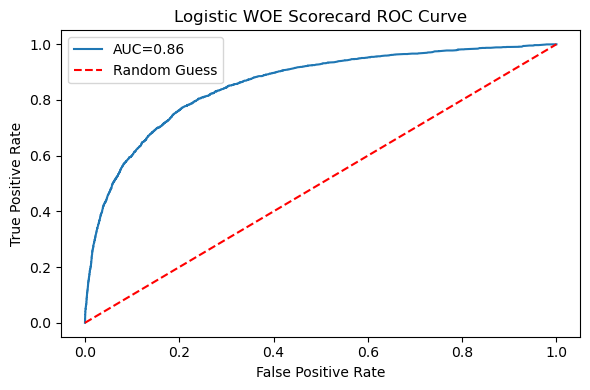

In [24]:
# 画 ROC 曲线，展示模型在不同阈值下的 TPR/FPR 表现
# 曲线越靠近左上角，说明模型排序能力越强
auc_value = model_metrics.loc[0, 'AUC']
fpr, tpr, thresholds = roc_curve(y_val, y_pro)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'AUC={auc_value:.2f}')
plt.plot([0, 1], [0, 1], 'r--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic WOE Scorecard ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Cutoff Strategy 分析
# 目的：把模型预测结果转换成实际风控策略，模拟不同拒绝比例下的业务效果
# reject_rate=0.10 表示拒绝预测风险最高的 10% 客户

def cutoff_strategy(y_true, y_prob, reject_rate):
    strategy_df = pd.DataFrame({
        'target': y_true,
        'pred_prob': y_prob
    })
    
    # 1. 按预测违约概率从高到低排序，排在最前面的是模型认为风险最高的客户
    strategy_df = strategy_df.sort_values('pred_prob', ascending=False).reset_index(drop=True)
    
    # 2. 根据拒绝率计算需要拒绝的客户数量
    reject_n = int(len(strategy_df) * reject_rate)
    
    # 3. 划分拒绝客群和通过客群
    rejected = strategy_df.iloc[:reject_n]#取0到reject_n-1行，reject_n取不到
    approved = strategy_df.iloc[reject_n:]
    
    # 4. 计算策略指标
    # approval_rate：通过率，即仍然被接受的客户比例
    # bad_capture_rate：坏客户拦截率，即被拒绝客户覆盖了多少真实坏客户
    # approved_bad_rate：通过客群坏账率，衡量策略执行后剩余客户的风险水平
    # rejected_bad_rate：拒绝客群坏账率，衡量被拒绝客户是否确实更高风险
    return {
        'reject_rate': reject_rate,
        'approval_rate': 1 - reject_rate,
        'bad_capture_rate': rejected['target'].sum() / strategy_df['target'].sum(),
        'approved_bad_rate': approved['target'].mean(),
        'rejected_bad_rate': rejected['target'].mean()
    }

# 对比不同拒绝比例下的策略效果
# 后续 report 可以用这张表说明模型如何支持授信审批策略
strategy_table = pd.DataFrame([
    cutoff_strategy(y_val, y_pro, 0.10),
    cutoff_strategy(y_val, y_pro, 0.20),
    cutoff_strategy(y_val, y_pro, 0.30)
])

strategy_table


,reject_rate,approval_rate,bad_capture_rate,approved_bad_rate,rejected_bad_rate
0,0.1,0.9,0.528216,0.034907,0.351846
1,0.2,0.8,0.710727,0.024079,0.236668
2,0.3,0.7,0.816472,0.017459,0.181244
